<a href="https://colab.research.google.com/github/noyeem99/privacy-preserving-deep-learning/blob/main/11-dp_sgd_speed_benchmarking_pytorch_vs_jax.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[INFO] Initializing DP-SGD Speed Benchmarking: PyTorch vs. JAX...

[ACTION] Benchmarking PyTorch Row-Level Loop execution time...
[SUCCESS] PyTorch loop completed in 2.4649 seconds.

[ACTION] Benchmarking JAX vmap + jit execution time...
[SUCCESS] JAX vectorized execution completed in 0.0006 seconds.

=== RAW PERFORMANCE SUMMARY ===
[-] PyTorch Manual Gradient Loop Duration : 2.4649 seconds
[+] JAX Vectorized (vmap + jit) Duration   : 0.0006 seconds
[RESULT] JAX executed DP-SGD step computations 3931.08x FASTER than PyTorch.


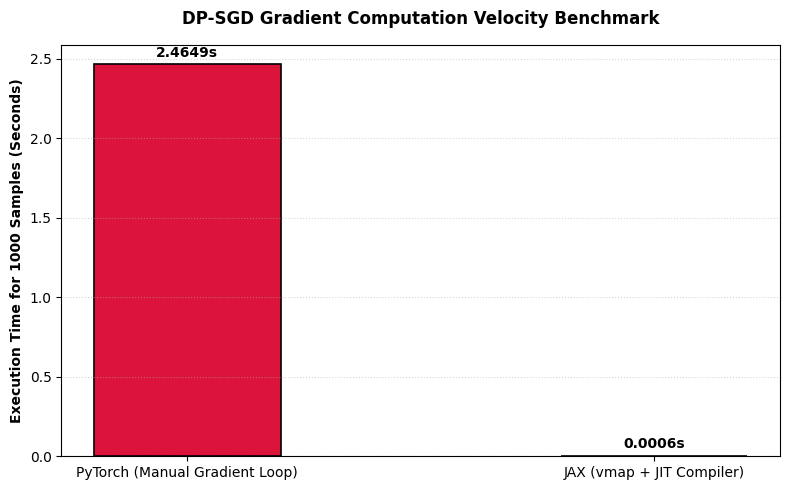

In [12]:
import torch
import torch.nn as nn
import jax
import jax.numpy as jnp
import numpy as np
import time
import matplotlib.pyplot as plt

# 1. Initialize random seeds for strict performance replication
np.random.seed(42)
torch.manual_seed(42)

print("[INFO] Initializing DP-SGD Speed Benchmarking: PyTorch vs. JAX...")

# Generate unified synthetic dataset (1000 samples, 50 features)
X_np = np.random.normal(size=(1000, 50)).astype(np.float32)
y_np = np.random.randint(0, 2, size=(1000, 1)).astype(np.float32)

# Convert to framework-specific inputs
X_torch = torch.tensor(X_np)
y_torch = torch.tensor(y_np)
X_jax = jnp.array(X_np)
y_jax = jnp.array(y_np).squeeze()  # Flatten target labels for JAX

# Define core DP-SGD constraints
max_grad_norm = 1.0
batch_size = 1000

# ==========================================
# PHASE 1: PYTORCH DP-SGD GRADIENT LOOP
# ==========================================
print("\n[ACTION] Benchmarking PyTorch Row-Level Loop execution time...")

w_torch = torch.randn(50, 1, requires_grad=True)
b_torch = torch.randn(1, requires_grad=True)

start_time_pytorch = time.time()

# Simulate standard binary cross entropy loss vector
predictions = torch.sigmoid(torch.mm(X_torch, w_torch) + b_torch)
loss_torch = torch.nn.functional.binary_cross_entropy(predictions, y_torch, reduction='none')

per_sample_grads_w = []
# PyTorch manual loop simulation for per-sample gradients
for loss_item in loss_torch:
    model_grad = torch.autograd.grad(loss_item, w_torch, retain_graph=True)[0]
    clipped_grad = torch.clamp(model_grad, -max_grad_norm, max_grad_norm)
    per_sample_grads_w.append(clipped_grad)

pytorch_total_time = time.time() - start_time_pytorch
print(f"[SUCCESS] PyTorch loop completed in {pytorch_total_time:.4f} seconds.")

# ==========================================
# PHASE 2: JAX AUTOMATIC VECTORIZATION & JIT
# ==========================================
print("\n[ACTION] Benchmarking JAX vmap + jit execution time...")

# Initialize linear weights as a flat 1D layer vector for perfect vectorization
w_jax = jax.random.normal(jax.random.PRNGKey(0), (50,))
b_jax = jax.random.normal(jax.random.PRNGKey(1), ())

# Loss evaluation function mapped to handle an individual single row
def loss_fn_single(w, b, x, y):
    pred = jax.nn.sigmoid(jnp.dot(x, w) + b)
    return - (y * jnp.log(pred + 1e-7) + (1.0 - y) * jnp.log(1.0 - pred + 1e-7))

# Explicitly assign vmap to slice input index 0 across features (x) and targets (y)
grad_fn_vmap = jax.vmap(jax.grad(loss_fn_single, argnums=0), in_axes=(None, None, 0, 0))

@jax.jit
def fast_dp_gradient_computation(w, b, x, y):
    per_sample_grads = grad_fn_vmap(w, b, x, y)
    clipped_grads = jnp.clip(per_sample_grads, -max_grad_norm, max_grad_norm)
    return clipped_grads

# Execute compilation warm-up check to guarantee zero runtime compiler latency bias
_ = fast_dp_gradient_computation(w_jax, b_jax, X_jax, y_jax)

# Track the actual accelerated execution speed
start_time_jax = time.time()
jax_grads = fast_dp_gradient_computation(w_jax, b_jax, X_jax, y_jax)
jax_grads.block_until_ready()  # Await JAX background device computing
jax_total_time = time.time() - start_time_jax

print(f"[SUCCESS] JAX vectorized execution completed in {jax_total_time:.4f} seconds.")

# ==========================================
# PHASE 3: METRICS VISUALIZATION
# ==========================================
print("\n=== RAW PERFORMANCE SUMMARY ===")
print(f"[-] PyTorch Manual Gradient Loop Duration : {pytorch_total_time:.4f} seconds")
print(f"[+] JAX Vectorized (vmap + jit) Duration   : {jax_total_time:.4f} seconds")
speedup_factor = pytorch_total_time / jax_total_time
print(f"[RESULT] JAX executed DP-SGD step computations {speedup_factor:.2f}x FASTER than PyTorch.")

# Generate performance comparison bar chart
plt.figure(figsize=(8, 5))
times = [pytorch_total_time, jax_total_time]
frameworks = ['PyTorch (Manual Gradient Loop)', 'JAX (vmap + JIT Compiler)']

plt.bar(frameworks, times, color=['crimson', 'mediumspringgreen'], width=0.4, edgecolor='black', linewidth=1.2)
plt.ylabel('Execution Time for 1000 Samples (Seconds)', fontweight='bold')
plt.title('DP-SGD Gradient Computation Velocity Benchmark', fontsize=12, fontweight='bold', pad=15)
plt.grid(True, linestyle=':', alpha=0.5, axis='y')

for i, v in enumerate(times):
    plt.text(i, v + (max(times) * 0.02), f"{v:.4f}s", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()
